In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot as plt # plotting
from math import * # sqrt() etc
# with %matplotlib inline you turn on the immediate display.
# %matplotlib inline

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os

# Concat dataframes
data = pd.DataFrame()
directory = "./input"
for filename in os.listdir(directory):
    f = os.path.join(directory, filename)
    if f.endswith('.csv'):
        df = pd.read_csv(f, low_memory=False)
        data = pd.concat([data, df])
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1889322 entries, 0 to 142839
Data columns (total 54 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   state_code                        object 
 1   district_code                     int64  
 2   rural_urban                       object 
 3   stratum                           int64  
 4   psu_id                            int64  
 5   ahs_house_unit                    int64  
 6   house_hold_no                     object 
 7   date_survey                       object 
 8   test_salt_iodine                  int64  
 9   record_code_iodine                object 
 10  record_code_iodine_reason         object 
 11  sl_no                             int64  
 12  sex                               int64  
 13  usual_residance                   object 
 14  usual_residance_reason            object 
 15  identification_code               object 
 16  age_code                          obj

### Cleaning data

In [8]:
data = data[(data['age_code']=='Y')&(data['age']>=18)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1077746 entries, 0 to 142839
Data columns (total 54 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   state_code                        1077746 non-null  object 
 1   district_code                     1077746 non-null  int64  
 2   rural_urban                       1077746 non-null  object 
 3   stratum                           1077746 non-null  int64  
 4   psu_id                            1077746 non-null  int64  
 5   ahs_house_unit                    1077746 non-null  int64  
 6   house_hold_no                     1077746 non-null  object 
 7   date_survey                       1077692 non-null  object 
 8   test_salt_iodine                  1077746 non-null  int64  
 9   record_code_iodine                1077743 non-null  object 
 10  record_code_iodine_reason         191023 non-null   object 
 11  sl_no                             1077

Original data has -1 for missing values

In [9]:
data = data.replace([-1, '-1'], np.nan)

Dropping columns only applicable to under 5 year olds

In [10]:
cols_under5 = ['illness_type', 'illness_duration', 'treatment_type']
cols_under3 = ['first_breast_feeding', 'is_cur_breast_feeding', 'day_or_month_for_breast_feeding_', 'day_or_month_for_breast_feeding', 'water_month', 'ani_milk_month', 'semisolid_month_or_day', 'solid_month', 'vegetables_month_or_day']
data = data.drop(cols_under5, axis = 1)
data = data.drop(cols_under3, axis = 1)

Dropping unnecessary features

- 'state_code'
- 'PSU_ID' - This is a seven digit number to uniquely identify each record.
- 'ahs_house_unit' - House Number
- 'house_hold_no' - Household Number
- 'record_code_iodine_reason' - Why was iodine testing refused
- 'sl_no' - Each record of the Household has a serial no.
- 'usual_residence' - Whether the member usually lives here
- 'usual_residence_reason' - Reason for member not being usual resident
- 'identification_code' - Each member of a PSU is assigned a unique number
- 'v54' ?

In [11]:
data = data.drop(['state_code', 'psu_id', 'ahs_house_unit', 'house_hold_no', 'record_code_iodine_reason', 'sl_no', 'usual_residance', 'usual_residance_reason', 'identification_code', 'v54'], axis = 1)

From data dictionary:

- 'rural_urban' - Rural-1; Urban-2
- 'stratum' - 1 or 2 when 'rural_urban'=1, 0 when 'rural_urban'=2
dropping feature 'rural_urban', since 'stratum' contains the same information

I guess 'stratum' feature values:

- 0 - urban
- 1 - rural
- 2 - very rural?

not specified in dictionary

In [12]:
data = data.drop('rural_urban', axis = 1)

Age related
From data dictionary:

- 'age_code' - unit of recording age
- 'age'
- 'date_of_birth' - DD
- 'month_of_birth' - MM
- 'year_of_birth' - YYYY

Dropping feature age_code(values: Y, M, D for years, months, days), since age is always recorded in years for adults

In [13]:
display(np.unique(data['age_code']))
data = data.drop('age_code', axis = 1)

array(['Y'], dtype=object)

<function matplotlib.pyplot.show(close=None, block=None)>

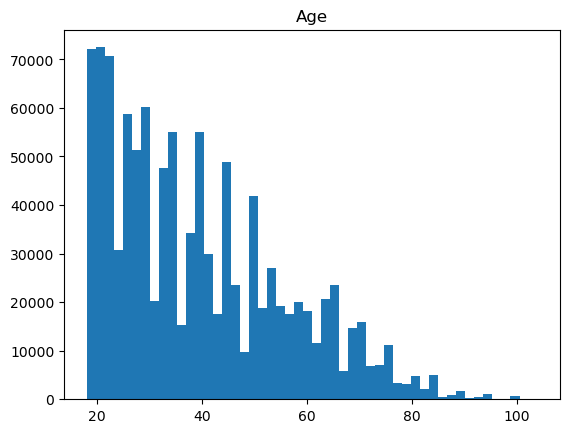

In [14]:
plt.hist(data.age.dropna(), bins = 50)
plt.title('Age')
plt.show

Iodine
From data dictionary:

- 'test_salt_iodine' - Salt used by the Household has been tested for Iodine content[Recorded as Parts Per Million(PPM)]
- 'record_code_iodine' - No iodine – 1; Less than 15 PPM – 2; More than or equal to 15 PPM – 3; No salt in Household – 4; Salt not tested – 5

In [15]:
pd.value_counts(data['record_code_iodine'])

3.0    866242
2.0    167653
1.0     43848
Name: record_code_iodine, dtype: int64

Height/weight
From data dictionary:

- 'weight_measured' - Measured-1; Member - not present-2, Refused-3, Other-4
- 'weight_in_kg' - outcome
- 'length_height_measured' - Measured-1; Member not present-2, Refused-3, Other-4
- 'length_height_code' - L- Length, H-Height
- 'length_height_cm' - outcome

Dropping, unnecessary columns, NA in weight/length column if measurement was not conducted

<function matplotlib.pyplot.show(close=None, block=None)>

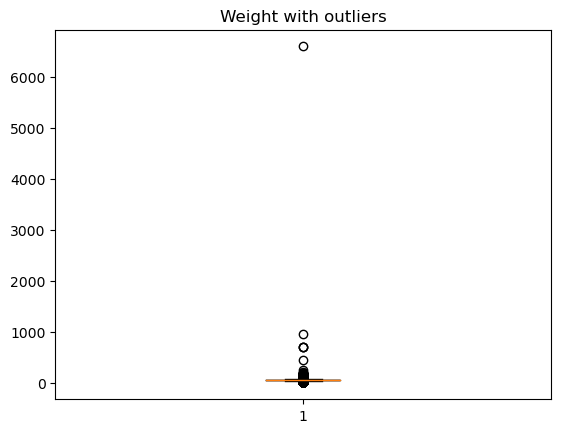

In [16]:
data = data.drop(['weight_measured', 'length_height_measured', 'length_height_code'], axis = 1)
data = data.rename(index=str, columns={"weight_in_kg": "weight", "length_height_cm": "height"})
plt.boxplot(data['weight'].dropna())
plt.title('Weight with outliers')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

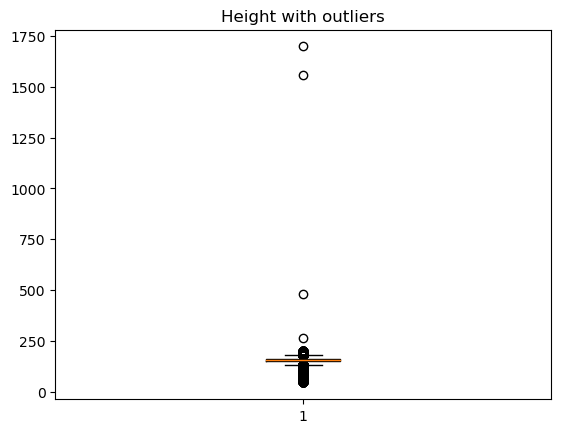

In [17]:
plt.boxplot(data['height'].dropna())
plt.title('Height with outliers')
plt.show

In [18]:
# exclude any measurements where difference from median is larger than 3 standard deviations
def remove_outliers(data, feature):
    stdev = sqrt(np.var(data[feature].dropna()))
    median = np.median(data[feature].dropna())
    print("number of discarded measurements")
    display(len(data[[feature]].where(abs(data[feature] - median)>(3*stdev)).dropna()))
# keep original values if difference from mean is less than 3 standard deviations. NA otherwise
    return data[[feature]].where(abs(data[feature] - median)<(3*stdev), other = np.nan)

data['height'] = remove_outliers(data, 'height')

number of discarded measurements


4177

Removing weight outliers. NA for anything under 20kg

In [19]:
print('number of discarded measurements')
display(len(data[data['weight']<20]))
data['weight'] = data['weight'].where(data['weight']>20, other=np.nan)

number of discarded measurements


3024

<function matplotlib.pyplot.show(close=None, block=None)>

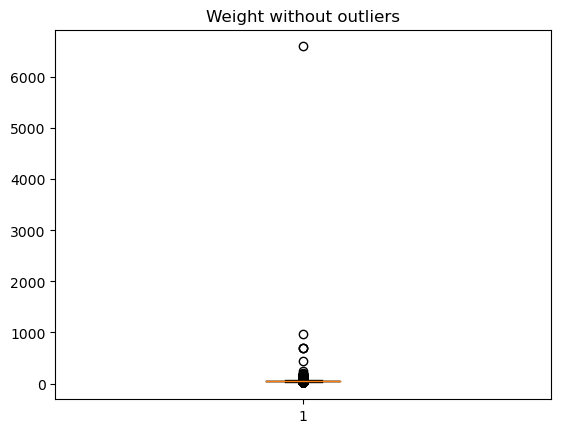

In [20]:
plt.boxplot(data['weight'].dropna())
plt.title('Weight without outliers')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

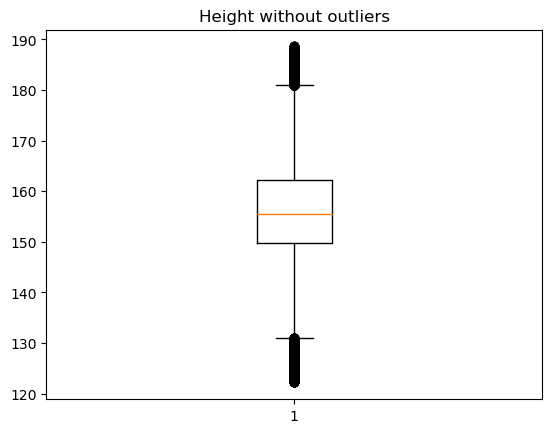

In [21]:
plt.boxplot(data['height'].dropna())
plt.title('Height without outliers')
plt.show

Body mass index: weight(kg)/(height(m) * height(m))

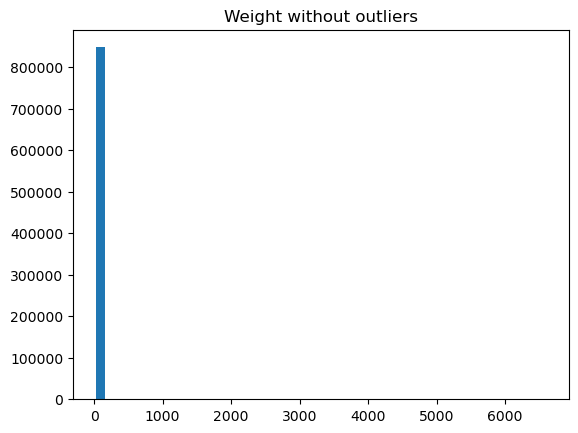

In [22]:
data['bmi'] = data['weight']/(data['height']/100)**2
plt.hist(data['weight'].dropna(), bins = 50)
plt.title('Weight without outliers')
plt.show()

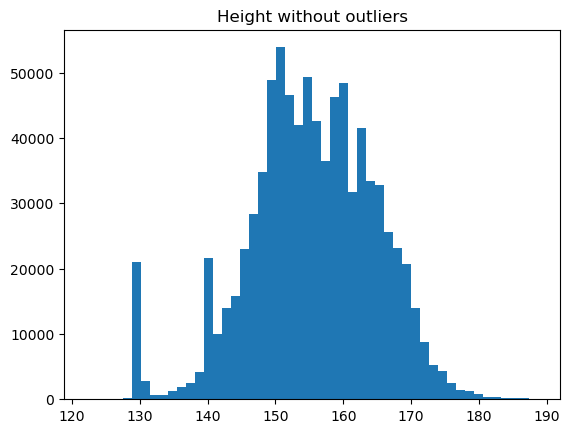

In [23]:
plt.hist(data['height'].dropna(), bins = 50)
plt.title('Height without outliers')
plt.show()


A lot of individuals with 130, 140, 150 cm height

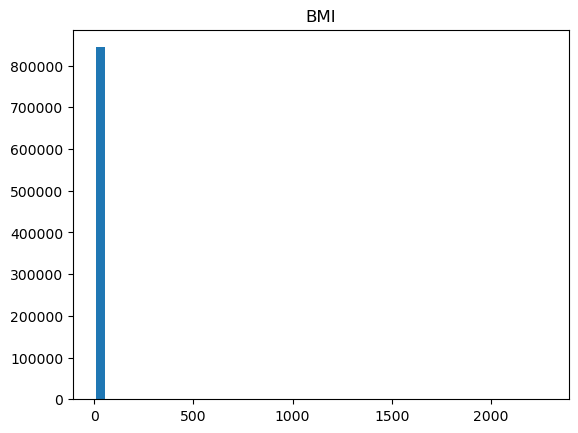

In [24]:
plt.hist(data['bmi'].dropna(), bins = 50)
plt.title('BMI')
plt.show()

Data cleaning steps for height/weight related data:

- Discarded any height measurements where difference from median was further than 3 standard deviations. Looking at distribution of height/weight as normally distributed.
- Discarded any weight measurements under 20kg
- Calculated BMI

Discarded ~800 values for height, ~460 values for weight. Out of ~200 000

### Pulse, blood pressure(heart disease)
From data dictionary:

- 'bp_systolic'
- 'bp_systolic_2_reading'
- 'bp_diastolic'
- 'bp_diastolic_2reading'
- 'pulse_rate',
- 'pulse_rate_2_reading'

In [25]:
# for features where two measurements were taken, exclude any where difference between measurements is larger than 3 standard deviations
def remove_outliers_difference(data, col1, col2):
    stdev = sqrt((data[col1] - data[col2]).var())
# how many measurements were excluded
    print('number of discarded measurements')
    display(len(data[[col1, col2]].where(abs(data[col1] - data[col2])>(3*stdev)).dropna()))
# keep original values if difference of two measurements is less than 3 standard deviations. NA otherwise
    return data[[col1, col2]].where(abs(data[col1] - data[col2])<(3*stdev), other = np.nan)

In [26]:
data[['bp_systolic', 'bp_systolic_2_reading']] = remove_outliers_difference(data, 'bp_systolic', 'bp_systolic_2_reading')
data[['bp_diastolic', 'bp_diastolic_2reading']] = remove_outliers_difference(data, 'bp_diastolic', 'bp_diastolic_2reading')
data[['pulse_rate', 'pulse_rate_2_reading']] = remove_outliers_difference(data, 'pulse_rate', 'pulse_rate_2_reading')

number of discarded measurements


13136

number of discarded measurements


16104

number of discarded measurements


14682

Now that outliers have been removed, aggregate remaining data by finding mean between two readings

In [27]:
# aggregate two reading by finding mean
def aggregate_readings(data, col1, col2):
    data[col1] = data.apply(lambda row: sum([row[col1], row[col2]])/2, axis = 1)
    data = data.drop(col2, axis = 1)
    return data

In [28]:
data = aggregate_readings(data, 'bp_systolic', 'bp_systolic_2_reading')
data = aggregate_readings(data, 'bp_diastolic', 'bp_diastolic_2reading')
data = aggregate_readings(data, 'pulse_rate', 'pulse_rate_2_reading')

Systolic - beating, diastolic - resting blood pressure. Likely input/measurement error where systolic < diastolic

In [29]:
# retain original values where resting blood pressure lower than beating. NA otherwise 
data[['bp_diastolic', 'bp_systolic']] = data[['bp_diastolic', 'bp_systolic']].where(data.bp_diastolic < data.bp_systolic, other = np.nan)

Data cleaning steps for heart disease related data:

- Discarded any where difference between two measurements was further from mean than 3 standard deviations. Looking at distribution of measurement differences as normally distributed.
- Aggregated two measurements by finding mean
- Discarded any where diastolic pressure was higher than systolic

Lost less than 5% of values for each feature

### Haemoglobin(anemia)
From data dictionary:

- 'haemoglobin_test' - Consent for Haemoglobin test (Yes-1; No-2)
- 'haemoglobin'- Status of Haemoglobin Test (Measured-1; Member not present-2; Refused-3, Other-4)
- 'haemoglobin_level' - Outcome of Haemoglobin Level (Hb) Test (in percentage gms)

<function matplotlib.pyplot.show(close=None, block=None)>

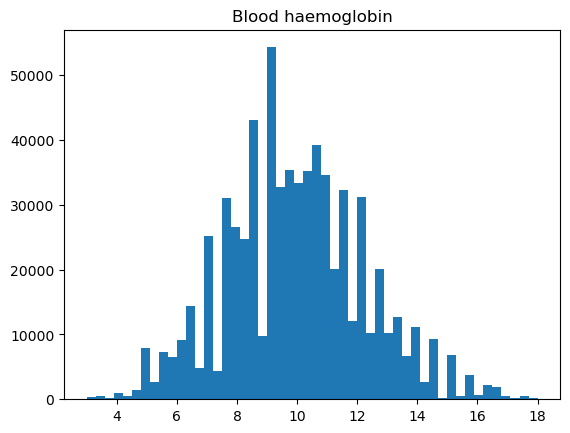

In [30]:
data = data.drop(['haemoglobin_test', 'haemoglobin'], axis = 1)

plt.hist(data.haemoglobin_level[~np.isnan(data.haemoglobin_level)], bins=50)
plt.title('Blood haemoglobin')
plt.show

### Blood sugar(diabetes)
From data dictionary:

- 'diabetes_test' - consent for testing
- 'fasting_blood_glucose' - Measured-1; Member not present-2; Refused-3; Other-4
- 'fasting_blood_glucose_mg_dl' - outcome of test

<function matplotlib.pyplot.show(close=None, block=None)>

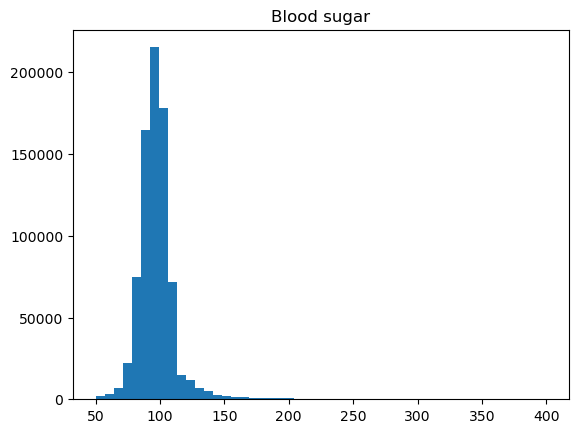

In [31]:
data = data.drop(['diabetes_test', 'fasting_blood_glucose'], axis = 1)

plt.hist(data.fasting_blood_glucose_mg_dl[~np.isnan(data.fasting_blood_glucose_mg_dl)], bins=50)
plt.title('Blood sugar')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

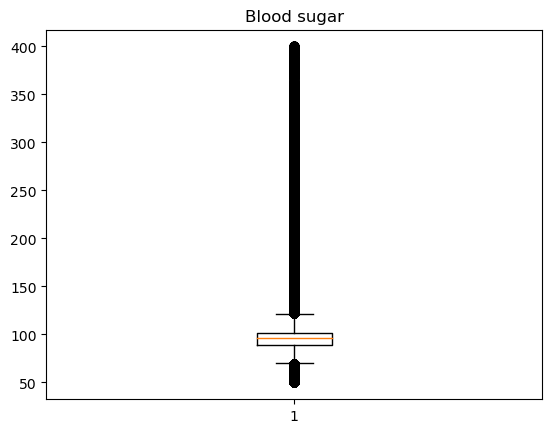

In [32]:
plt.boxplot(data.fasting_blood_glucose_mg_dl[~np.isnan(data.fasting_blood_glucose_mg_dl)])
plt.title('Blood sugar')
plt.show

In [33]:
data['fasting_blood_glucose_mg_dl'] = remove_outliers(data,'fasting_blood_glucose_mg_dl')

number of discarded measurements


11694

### Features only applicable to women
From data dictionary:

- 'marital_status' - Never married=1,Married but Gauna not performed=2, Married and Gauna perfomed=3, Remarried=4,Widow=5, Divorced=6, Separated=7, Not stated=8
- 'gauna_perfor_not_perfor' - Pregnant-1; Lactating-2; Non-pregnant or Non-lactating-3
- 'duration_pregnanacy' - Duration of pregnancy/lactation (in months)

In [34]:
cols_women = ['marital_status', 'gauna_perfor_not_perfor', 'duration_pregnanacy']

placing NA where marital status 'not stated'

<function matplotlib.pyplot.show(close=None, block=None)>

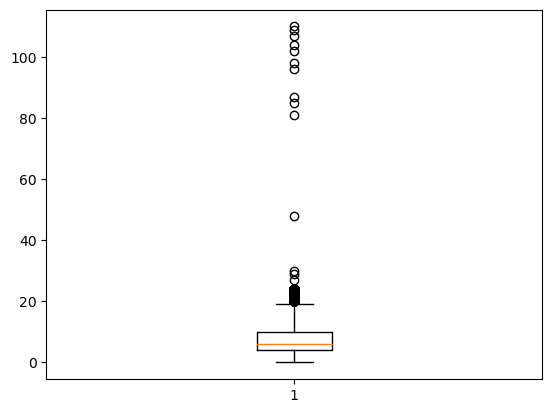

In [35]:
data['marital_status'] = data['marital_status'].where(~(data['marital_status']==8.0), other = np.nan)

# input errors have to be dealt with
plt.boxplot(data['duration_pregnanacy'].dropna())
plt.show

In [36]:
corr=data.corr()[['haemoglobin_level', 'pulse_rate', 'bp_diastolic', 'bp_systolic', 'fasting_blood_glucose_mg_dl']]
corr.where(abs(corr)>0.1)

/var/folders/f1/0yj42_z534vdm_23tfttdpt80000gn/T/ipykernel_21867/2526902260.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr=data.corr()[['haemoglobin_level', 'pulse_rate', 'bp_diastolic', 'bp_systolic', 'fasting_blood_glucose_mg_dl']]


,haemoglobin_level,pulse_rate,bp_diastolic,bp_systolic,fasting_blood_glucose_mg_dl
district_code,-0.123859,NaN,NaN,NaN,NaN
stratum,NaN,NaN,NaN,NaN,NaN
test_salt_iodine,NaN,NaN,NaN,NaN,NaN
record_code_iodine,NaN,NaN,NaN,NaN,NaN
sex,-0.168959,0.151910,NaN,NaN,NaN
age,NaN,NaN,0.176803,0.317395,0.188077
date_of_birth,NaN,NaN,NaN,NaN,NaN
month_of_birth,NaN,NaN,NaN,NaN,NaN
year_of_birth,NaN,NaN,-0.175762,-0.315015,-0.186814
weight,0.113722,NaN,0.219739,0.132767,NaN


Removing features where there's no correlation

In [37]:
data_correlated = data.drop(['district_code', 'stratum', 'test_salt_iodine', 'record_code_iodine', 'date_of_birth', 'month_of_birth', 'duration_pregnanacy'], axis = 1)
corr = data_correlated.corr()[['haemoglobin_level', 'pulse_rate', 'bp_diastolic', 'bp_systolic', 'fasting_blood_glucose_mg_dl']]
corr.where(abs(corr)>0.1)

/var/folders/f1/0yj42_z534vdm_23tfttdpt80000gn/T/ipykernel_21867/814415761.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = data_correlated.corr()[['haemoglobin_level', 'pulse_rate', 'bp_diastolic', 'bp_systolic', 'fasting_blood_glucose_mg_dl']]


,haemoglobin_level,pulse_rate,bp_diastolic,bp_systolic,fasting_blood_glucose_mg_dl
sex,-0.168959,0.151910,NaN,NaN,NaN
age,NaN,NaN,0.176803,0.317395,0.188077
year_of_birth,NaN,NaN,-0.175762,-0.315015,-0.186814
weight,0.113722,NaN,0.219739,0.132767,NaN
height,0.179682,NaN,0.115793,NaN,NaN
haemoglobin_level,1.000000,NaN,NaN,NaN,NaN
bp_systolic,NaN,NaN,0.668181,1.000000,0.133630
bp_diastolic,NaN,0.211948,1.000000,0.668181,NaN
pulse_rate,NaN,1.000000,0.211948,NaN,NaN
fasting_blood_glucose_mg_dl,NaN,NaN,NaN,0.133630,1.000000


Summary
From 53 initial features to 21

TODO:

A lot of individuals with 130, 140, 150cm height value??

In [38]:
data

,district_code,stratum,date_survey,test_salt_iodine,record_code_iodine,sex,age,date_of_birth,month_of_birth,year_of_birth,...,height,haemoglobin_level,bp_systolic,bp_diastolic,pulse_rate,fasting_blood_glucose_mg_dl,marital_status,gauna_perfor_not_perfor,duration_pregnanacy,bmi
0,1,1,6/11/2014,15,3.0,1,31.0,15.0,6.0,1983.0,...,171.39999,9.8,137.0,94.5,71.5,105.0,NaN,NaN,NaN,25.563384
1,1,1,6/11/2014,15,3.0,2,26.0,15.0,6.0,1988.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,6/11/2014,15,3.0,1,65.0,15.0,6.0,1949.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1,6/11/2014,15,3.0,2,60.0,15.0,6.0,1954.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1,6/11/2014,15,3.0,1,35.0,15.0,6.0,1979.0,...,162.30000,9.2,95.0,49.5,62.0,82.0,NaN,NaN,NaN,16.627887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142835,23,0,03/07/2014,7,2.0,1,95.0,0.0,0.0,1919.0,...,160.10001,8.0,114.5,78.5,78.0,NaN,NaN,NaN,NaN,15.956609
142836,23,0,05/07/2014,7,2.0,1,95.0,0.0,4.0,1919.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142837,23,0,05/07/2014,30,3.0,1,98.0,0.0,0.0,1916.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142838,23,0,04/07/2014,30,3.0,2,99.0,0.0,0.0,1915.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1077746 entries, 0 to 142839
Data columns (total 21 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   district_code                1077746 non-null  int64  
 1   stratum                      1077746 non-null  int64  
 2   date_survey                  1077692 non-null  object 
 3   test_salt_iodine             1077746 non-null  int64  
 4   record_code_iodine           1077743 non-null  float64
 5   sex                          1077746 non-null  int64  
 6   age                          1077746 non-null  float64
 7   date_of_birth                1077746 non-null  float64
 8   month_of_birth               1077746 non-null  float64
 9   year_of_birth                1077746 non-null  float64
 10  weight                       847551 non-null   float64
 11  height                       845505 non-null   float64
 12  haemoglobin_level            682848 non-null   f

In [41]:
data = data.drop(['district_code', 'stratum', 'date_survey', 'test_salt_iodine', 'record_code_iodine', 'date_of_birth', 'month_of_birth', 'year_of_birth',
                  'marital_status', 'gauna_perfor_not_perfor', 'duration_pregnanacy'], axis = 1)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1077746 entries, 0 to 142839
Data columns (total 10 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   sex                          1077746 non-null  int64  
 1   age                          1077746 non-null  float64
 2   weight                       847551 non-null   float64
 3   height                       845505 non-null   float64
 4   haemoglobin_level            682848 non-null   float64
 5   bp_systolic                  819790 non-null   float64
 6   bp_diastolic                 819790 non-null   float64
 7   pulse_rate                   831743 non-null   float64
 8   fasting_blood_glucose_mg_dl  782786 non-null   float64
 9   bmi                          844231 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 90.4+ MB


In [45]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617595 entries, 0 to 142839
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   sex                          617595 non-null  int64  
 1   age                          617595 non-null  float64
 2   weight                       617595 non-null  float64
 3   height                       617595 non-null  float64
 4   haemoglobin_level            617595 non-null  float64
 5   bp_systolic                  617595 non-null  float64
 6   bp_diastolic                 617595 non-null  float64
 7   pulse_rate                   617595 non-null  float64
 8   fasting_blood_glucose_mg_dl  617595 non-null  float64
 9   bmi                          617595 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 51.8+ MB


In [46]:
data

,sex,age,weight,height,haemoglobin_level,bp_systolic,bp_diastolic,pulse_rate,fasting_blood_glucose_mg_dl,bmi
0,1,31.0,75.099998,171.39999,9.8,137.0,94.5,71.5,105.0,25.563384
4,1,35.0,43.799999,162.30000,9.2,95.0,49.5,62.0,82.0,16.627887
5,2,32.0,39.700001,150.30000,14.5,98.0,60.0,81.5,78.0,17.574078
11,1,50.0,42.099998,151.70000,11.0,140.5,90.5,79.0,112.0,18.294094
12,2,46.0,54.299999,148.10001,8.4,126.0,84.0,87.0,114.0,24.756523
...,...,...,...,...,...,...,...,...,...,...
142826,2,43.0,38.200001,152.39999,9.0,133.0,78.0,69.0,91.0,16.447258
142827,2,43.0,42.299999,148.50000,12.0,110.0,72.0,75.0,86.0,19.181716
142829,1,90.0,49.799999,163.10001,8.0,130.5,70.0,71.5,108.0,18.720669
142832,1,94.0,42.000000,150.00000,10.5,126.5,54.0,65.0,117.0,18.666667


In [47]:
data.to_csv('indios_limpio.csv')

In [ ]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit_transform(data)